## Plotting cases of SNS categories

Please see `example.ipynb` for an example on how to use the provided data. 

In this notebook, we make all the plots that are in the cases subdirectories.

Used software:
```
 python   3.8.19
  scipy   1.10.1 
 xarray 2023.1.0
  numpy   1.24.4 
cartopy   0.21.0 
```

In [3]:
# Standard imports
import os
from typing import Tuple, Optional, Union


import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import scipy.stats

import xarray as xr

In [4]:
# -----------------------------
# Small helper utilities
# -----------------------------
def get_scalar(da_or_ds_field) -> Union[str, float, int]:
    """
    Safely extract a single scalar value from an xarray DataArray / Dataset field.
    Works even if the field is a 0-D array. Falls back to str if needed.

    Returns
    -------
    A scalar (string, float, or int) extracted from the xarray field.
    """
    try:
        # xarray DataArray or Dataset variable → .values.item()
        return da_or_ds_field.values.item()
    except Exception:
        try:
            # numpy scalar or 0-D array
            return np.asarray(da_or_ds_field).item()
        except Exception:
            # Strings or other scalar-like things
            return str(da_or_ds_field)


def compute_center(
    ds_key: xr.Dataset,
    high_lat_threshold: float = 70.0,
) -> Tuple[float, float]:
    """
    Compute central latitude/longitude for the NearsidePerspective view.

    - Latitude: simple NaN-mean over the 'lat' values inside the selected map region.
    - Longitude: circular mean (−180..180) inside the selected region to avoid wrap-around issues.
    - If |lat| >= high_lat_threshold, force central longitude to 0 for better polar views.

    Returns
    -------
    (lat_mean, lon_mean)
    """
    # Mask the coordinates to only consider the selected region (where map is True / non-zero)
    lat_masked = ds_key.lat.where(ds_key["map"])
    lon_masked = ds_key.lon.where(ds_key["map"])

    # Mean latitude, ignoring NaNs
    lat_mean = float(np.nanmean(lat_masked))

    # Circular mean for longitudes (range -180..180)
    lon_mean = float(
        scipy.stats.circmean(
            lon_masked, high=180, low=-180, nan_policy="omit"
        )
    )

    # For higher latitudes, center at lon=0 to get a sensible view near the pole
    if abs(lat_mean) >= high_lat_threshold:
        lon_mean = 0.0

    return lat_mean, lon_mean


def validate_required_fields(ds_key: xr.Dataset) -> None:
    """
    Raise a helpful error if any required fields are missing.
    """
    required = [
        "lat", "lon", "map",
        "time", "time_series",
        "key",
        "variable_id", "units",
        "group", "case_number", "source_id", "sns_criterion",
    ]
    missing = [name for name in required if name not in ds_key]
    if missing:
        raise ValueError(
            f"The dataset is missing required fields: {missing}. "
            "Please ensure the dataset contains these variables."
        )


def build_title(ds_key: xr.Dataset) -> str:
    """
    Construct the multi-line figure title from dataset metadata fields.
    """
    case = get_scalar(ds_key.case_number)
    category = get_scalar(ds_key["group"])
    sns_cat = get_scalar(ds_key.sns_criterion)
    key = get_scalar(ds_key.key)

    return (f'Case number "{case}". Category "{category}". '
            f'SNS category "{sns_cat}".\n{key}')


def create_axes(
    lat_mean: float,
    lon_mean: float,
    figsize: Tuple[float, float] = (12, 4),
) -> Tuple[plt.Figure, dict]:
    """
    Create the figure with a mosaic layout:
      - 'a' (twice wide): Time series
      - 'b' (one column): NearsidePerspective map

    Returns
    -------
    fig, axes_dict
    """
    # Use a readable mosaic layout shape instead of the string "aab"
    layout = [
        ["a", "a", "b"]
    ]

    fig, axes = plt.subplot_mosaic(
        layout,
        figsize=figsize,
        per_subplot_kw={
            "b": {
                "projection": ccrs.NearsidePerspective(
                    satellite_height=1e7,
                    central_latitude=lat_mean,
                    central_longitude=lon_mean,
                )
            }
        },
        constrained_layout=False,  # We'll use bbox_inches="tight" when saving
    )
    return fig, axes


def plot_time_series(ax: plt.Axes, ds_key: xr.Dataset) -> None:
    """
    Plot the time series on the given axes, with labels from variable metadata.
    """
    ax.plot(
        ds_key.time,                      # Time coordinate
        ds_key.time_series.squeeze(),     # Series values
    )

    variable_id = get_scalar(ds_key.variable_id)
    units = get_scalar(ds_key.units)

    ax.set_ylabel(f"{variable_id} [{units}]")
    ax.set_xlabel("Time [year]")
    ax.set_title("Time series")


def plot_region(ax: plt.Axes, ds_key: xr.Dataset) -> None:
    """
    Draw the selected region on a Cartopy map as a red contour around the mask.
    """
    ax.coastlines()
    # Draw a thick red contour around the selected mask (map)
    ds_key["map"].plot.contour(
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        levels=[0, 1, 2],
        colors=["red"],
        linewidths=3,
        ax=ax,
    )
    ax.set_title("Selected region")
    gl = ax.gridlines(draw_labels=True)
    # Optional: control label sides for cleaner look
    gl.top_labels = False
    gl.right_labels = False


def build_output_dir(case: Union[int, str], category: str, source_id: str) -> str:
    """
    Build and create the output directory path for a given case/category/source.
    """
    directory = os.path.join(
        ".", "cases", f"case_{int(case):03}_category_{category}_{source_id}"
    )
    os.makedirs(directory, exist_ok=True)
    return directory


def safe_filename(name: str) -> str:
    """
    Make a simple safe filename from an arbitrary string.
    """
    # Replace spaces and problematic path characters
    return (
        str(name)
        .replace("/", "-")
        .replace("\\", "-")
        .replace(" ", "_")
    )


def save_figure(fig: plt.Figure, ds_key: xr.Dataset, output_dir: str, dpi: int = 100) -> None:
    """
    Save the figure as PNG and PDF under the output directory, using 'key' as filename.
    """
    key = safe_filename(get_scalar(ds_key.key))
    png_path = os.path.join(output_dir, f"{key}.png")
    pdf_path = os.path.join(output_dir, f"{key}.pdf")

    fig.savefig(png_path, bbox_inches="tight", dpi=dpi)
    fig.savefig(pdf_path, bbox_inches="tight", dpi=dpi)


# -----------------------------
# Main entry point
# -----------------------------
def plot_case(
    ds_key: xr.Dataset,
    show: bool = True,
    high_lat_threshold: float = 70.0,
    figsize: Tuple[float, float] = (12, 4),
    dpi: int = 100,
) -> None:
    """
    Create a time-series + map plot for a single case in an xarray Dataset.

    Parameters
    ----------
    ds_key : xr.Dataset
        A dataset *already subset to a single case* (e.g., ds.isel(key=i)).
        Must contain:
          - Coordinates/arrays: lat, lon, map (mask), time, time_series
          - Metadata scalars: key, variable_id, units, group, case_number, source_id, sns_criterion
    show : bool, default True
        Whether to display the figure via plt.show() (useful for the first case).
    high_lat_threshold : float, default 70.0
        If |mean latitude| >= this threshold, the map centers on longitude = 0.
    figsize : tuple(float, float), default (12, 4)
        Size of the figure in inches.
    dpi : int, default 100
        Resolution for saved images.

    Returns
    -------
    None (saves PNG and PDF to disk)
    """
    # 1) Validate required fields
    validate_required_fields(ds_key)

    # 2) Compute map center
    lat_mean, lon_mean = compute_center(ds_key, high_lat_threshold=high_lat_threshold)

    # 3) Prepare figure/axes
    fig, axes = create_axes(lat_mean=lat_mean, lon_mean=lon_mean, figsize=figsize)

    # 4) Plot time series
    ax_ts = axes["a"]
    plot_time_series(ax_ts, ds_key)

    # 5) Plot selected region on the map
    ax_map = axes["b"]
    plot_region(ax_map, ds_key)

    # 6) Add a clear, multi-line super title
    fig.suptitle(build_title(ds_key), y=1.04)

    # 7) Save to folder specific to this case/category/source
    category = get_scalar(ds_key["group"])
    case_num = get_scalar(ds_key.case_number)
    source_id = get_scalar(ds_key.source_id)
    out_dir = build_output_dir(case=case_num, category=str(category), source_id=str(source_id))

    save_figure(fig, ds_key, output_dir=out_dir, dpi=dpi)

    # 8) Show optionally, then close to free memory
    if show:
        plt.show()

    plt.close(fig)


Plotting 000/538


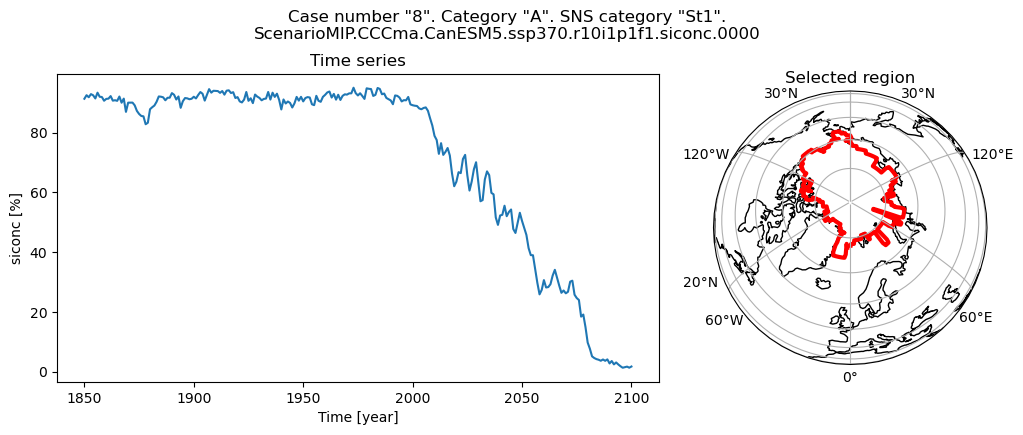

Plotting 025/538
Plotting 050/538
Plotting 075/538
Plotting 100/538
Plotting 125/538
Plotting 150/538
Plotting 175/538
Plotting 200/538
Plotting 225/538
Plotting 250/538
Plotting 275/538
Plotting 300/538
Plotting 325/538
Plotting 350/538
Plotting 375/538
Plotting 400/538
Plotting 425/538
Plotting 450/538
Plotting 475/538
Plotting 500/538
Plotting 525/538


In [6]:
ds = xr.load_dataset("dramatic_sns_cases.nc")
n_total=len(ds.key.values)
for i in range(n_total):
    if i%25==0 or i ==n_total:
        print(f'Plotting {i:03}/{n_total}')
    # Show only the first item, for reference. All others are simply saved to file
    do_show_if_i_equals_zero = i == 0
    plot_case(ds_key=ds.isel(key=i), show=do_show_if_i_equals_zero)